# 03 — Marge initiale du Future MASI 20
**Achraf Akiyaf — Master MMSD**

Question : quelle marge une CCP devrait-elle exiger ? On compare 3 modèles (gaussien, historique, EVT) et on analyse la procyclicité.

In [5]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data_utils import load_masi, audit_and_clean, log_returns, stylized_facts
from src import evt, margin, backtest as bt
from src.garch_evt import fit_garch_evt
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3})

masi = load_masi('../data/raw/masi.csv')
masi, journal = audit_and_clean(masi)
r = log_returns(masi); losses = -r
print('Période:', masi.index.min().date(),'->',masi.index.max().date(),'|',len(masi),'jours')
print('Corrections:', journal)

Période: 2010-01-12 -> 2026-07-10 | 4109 jours
Corrections: ['Aucune anomalie détectée — données propres.']


## 1. Les trois modèles de marge (MPOR 2 jours, α = 99.5%)
IM (MAD) = VaR₂ⱼ (%) × niveau indice × 10 MAD/point.

In [6]:
idx_now = masi.iloc[-1]
print(f'Niveau MASI actuel : {idx_now:,.0f} points\n')
print(f"{'Modèle':<14}{'Marge %':>10}{'Marge MAD':>14}")
for name, fn in [('Gaussien',margin.gaussian_margin),('Historique',margin.filtered_hist_margin),('EVT',margin.evt_margin)]:
    mp = fn(r, 0.995, 2); mm = margin.margin_to_mad(mp, idx_now)
    print(f'{name:<14}{mp:>9.2f}%{mm:>13,.0f}')
print('\nDépôt de garantie de référence communiqué : 1 000 MAD')

Niveau MASI actuel : 17,988 points

Modèle           Marge %     Marge MAD
Gaussien           2.83%        5,084
Historique         3.69%        6,631
EVT                3.96%        7,127

Dépôt de garantie de référence communiqué : 1 000 MAD


## 2. Évolution des marges dans le temps (walk-forward)

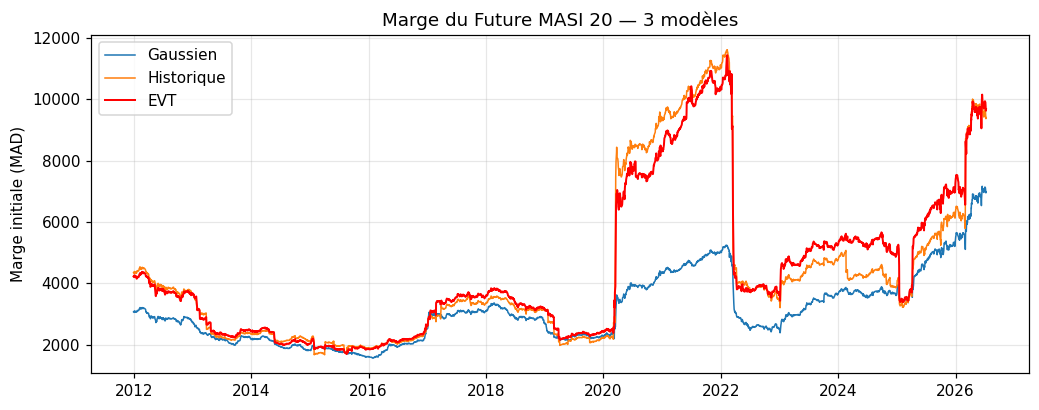

In [7]:
m_evt  = margin.margin_timeseries(r, masi, 'evt', window=500)
m_gauss= margin.margin_timeseries(r, masi, 'gaussian', window=500)
m_hist = margin.margin_timeseries(r, masi, 'hist', window=500)
plt.figure(figsize=(11,4))
plt.plot(m_gauss.index, m_gauss.margin_mad, label='Gaussien', lw=1)
plt.plot(m_hist.index, m_hist.margin_mad, label='Historique', lw=1)
plt.plot(m_evt.index, m_evt.margin_mad, label='EVT', lw=1.3, color='red')
plt.ylabel('Marge initiale (MAD)'); plt.title('Marge du Future MASI 20 — 3 modèles')
plt.legend(); plt.show()

## 3. Procyclicité (le débat des CCP depuis 2020)
Une marge qui explose en crise crée des appels de marge au pire moment.

In [8]:
proc = margin.procyclicality(m_evt.margin_mad)
print(f"Ratio pic/plancher : {proc['peak_to_trough_ratio']:.1f}x")
print(f"Hausse max sur 1 mois : {proc['max_monthly_rise_pct']:.0f}%")
print('\nInterprétation : une marge EVT inconditionnelle est très réactive '
'aux crises. Piste : version conditionnelle GARCH-EVT ou buffer anti-procyclique.')

Ratio pic/plancher : 6.7x
Hausse max sur 1 mois : 186%

Interprétation : une marge EVT inconditionnelle est très réactive aux crises. Piste : version conditionnelle GARCH-EVT ou buffer anti-procyclique.
